# Fit parameters and scale the simulation

CPU companion; no accelerator is required. TPU execution not validated.

- Fit a constrained physical parameter through an executed simulator.
- Separate training fit, held-out prediction and solver refinement.
- Diagnose unidentifiable observations and discretization-induced parameter bias.
- Measure synchronized batched CPU execution without claiming accelerator scaling.

Suppose we can observe cooling trajectories but do not know the rate. Can we recover it without confusing optimizer success with a trustworthy physical inference? We will fit a positive rate, test new initial conditions, examine non-identifiability, and measure a batched CPU workload with explicit timing boundaries.

## The idea

An inverse problem uses observations to infer parameters of a forward model. A small fitting error is meaningful only if the observations contain information about those parameters and the forward model matches the observation process.

## Ask whether observations identify the parameter

For exponential decay $y(t)=y_0e^{-at}$, an observation only at $t=0$ equals $y_0$ for every rate $a$. No optimizer can recover the rate from that observation alone. Later observations supply rate information, provided their noise and timing are understood.

The fitting loop changes the parameter, runs the solver at the declared observation times and compares with the data. Keep those times fixed when comparing candidate parameters. Solver error can otherwise be mistaken for a physical parameter effect.

Read the fitted trajectory alongside the residuals and objective history. A decreasing objective shows progress on that objective; it does not establish uniqueness or uncertainty. Test a changed observation schedule to see which part of the result is supported by data.

### Pause and reason

Can zero fitting error imply that the parameter is uniquely identified?

<details><summary>Compare your reasoning</summary>

No. Several parameter settings can fit the same insufficient observations. Examine identifiability and changed observation conditions, not only residual size.

</details>

## Choose data that can reveal the parameter

We generate observations from the exponential at forty-one times for initial values $0.7$, $1.5$ and $2.3$. The analytic generator is independent of RK4, avoiding a perfect fit caused merely by using exactly the same numerical algorithm twice. The data are noiseless and synthetic. Their provenance and split must remain explicit in any report.

## Enforce positivity through a parameterization

An unconstrained update to $k$ could make the cooling rate negative, turning decay into growth. Instead train $\theta=\log k$. The chain rule gives $dL/d\theta=k\,dL/dk$; this changes the optimization geometry as well as enforcing positivity. We start at $k=1.4$, twice the true value, and use an explicit fixed learning rate. No claim is made that this rate is suitable for other units or systems.

$$
\theta_{m+1}=\theta_m-\eta\frac{dL(e^{\theta_m})}{d\theta_m},\qquad k_m=e^{\theta_m}>0
$$

## Inspect the recovered model beyond the training curve

The recovered rate is about $0.700000009$, close to the known $0.7$. The tiny difference is numerical: RK4 slightly approximates the exponential. We test new initial conditions $0.4$, $1.1$ and $3.2$, then halve the simulation step. A fitted parameter that changes materially under grid refinement may be compensating for solver error. Good held-out performance here tests the same equation on new starts; it does not establish generalization to a different physical law. On this noiseless fixture, the fitted rate compensates for the tiny RK4 bias: the original-grid held-out error is near roundoff, while finer-grid error is about $7.3\times10^{-9}$. Refinement can therefore increase this already tiny residual. The check requires a small error, not automatic improvement.

## Recognize observations that cannot identify a parameter

At time zero the state equals the prescribed initial condition regardless of the rate. If the dataset contains only initial observations, the loss gradient is zero for every rate and no optimizer can recover it. This is non-identifiability, not a learning-rate problem. With noisy data, late-time points may also carry little useful signal after the system has nearly decayed. Inspect sensitivities and measurement precision before collecting more equally uninformative data.

## Keep numerical bias separate from physical estimates

For an Euler step, matching an exact exponential interval means $1-k_{\mathrm{Euler}}h=e^{-k_{\mathrm{true}}h}$. Thus a coarse Euler fit can perfectly match these observations using the wrong physical rate. With $h=0.5$, a true rate of $0.7$ looks like about $0.5906$. Low training error is not enough to justify the inferred parameter.

$$
k_{\mathrm{Euler}}=\frac{1-e^{-k_{\mathrm{true}}h}}{h}
$$

## Measure a bounded scaling experiment

Compile and warm up each batch shape, place its inputs before the timed region, and wait for results with block_until_ready. Report both total milliseconds and time per trajectory. Changing batch shape may compile a new program. This CPU experiment measures a fixed forty-step output-producing solve; it does not measure training, input transfer, multi-host communication or TPU performance. A batch can amortize overhead without implying unlimited scaling.

## Move from this audit to a scientific workflow

The staged scientific-inverse project asks for a reusable simulation and fitting API with changed parameters, noisy observations, held-out checks and a reproducible report. For stiff or adaptive models, choose and validate a suitable solver before reusing the optimizer. Diffrax, Equinox and Lineax provide ecosystem building blocks, but this phase’s executed core intentionally uses the installed JAX environment; no optional library or target hardware execution is implied.

## Define the simulator and immutable observations

Append this block to main.py in your CPU course environment; for the first block create the file. Run blocks in order.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np

def rk4_step(rate, value, dt):
    a = -rate*value
    b = -rate*(value + dt*a/2)
    c = -rate*(value + dt*b/2)
    d = -rate*(value + dt*c)
    return value + dt*(a + 2*b + 2*c + d)/6

def solve(rate, initial, steps=40, dt=0.05):
    def advance(value, unused):
        next_value = rk4_step(rate, value, dt)
        return next_value, next_value
    _, tail = jax.lax.scan(advance, initial, None, length=steps)
    return jnp.concatenate((jnp.atleast_1d(initial), tail))

train_initials = jnp.array([0.7,1.5,2.3])
times = jnp.arange(41)*0.05
true_rate = 0.7
observations = train_initials[:,None]*jnp.exp(-true_rate*times)
def predict(rate, initials):
    return jax.vmap(lambda initial: solve(rate,initial))(initials)
def objective(log_rate):
    residual = predict(jnp.exp(log_rate),train_initials)-observations
    return jnp.mean(residual**2)

Observations come from the analytic physical model, not the same discrete solver used for fitting. Different initial values are reserved for evaluation.

## Fit a positive rate with an explicit update

Append this block to main.py in your CPU course environment; for the first block create the file. Run blocks in order.

In [2]:
@jax.jit
def update(log_rate):
    return log_rate - 0.4*jax.grad(objective)(log_rate)
log_rate = jnp.log(1.4)
loss_history = [float(objective(log_rate))]
rate_history = [float(jnp.exp(log_rate))]
for _ in range(160):
    log_rate = update(log_rate)
    loss_history.append(float(objective(log_rate)))
    rate_history.append(float(jnp.exp(log_rate)))
fitted_rate = float(jnp.exp(log_rate))
assert abs(fitted_rate-true_rate) < 2e-7
assert loss_history[-1] < 1e-20
print("Initial/fitted rate:",rate_history[0],fitted_rate)
print("Initial/final loss:",loss_history[0],loss_history[-1])

Initial/fitted rate: 1.4 0.7000000090128304
Initial/final loss: 0.11676630453561089 1.9484774169068916e-32


The logarithm parameterization keeps the rate positive. The recorded first point is before any update; every later point evaluates the updated parameter.

## Validate on unseen initial conditions and a finer grid

Append this block to main.py in your CPU course environment; for the first block create the file. Run blocks in order.

In [3]:
held_initials=jnp.array([0.4,1.1,3.2])
held_truth=np.asarray(held_initials)[:,None]*np.exp(-true_rate*np.asarray(times))
held_prediction=np.asarray(predict(fitted_rate,held_initials))
held_rmse=float(np.sqrt(np.mean((held_prediction-held_truth)**2)))
assert held_rmse < 1e-7
fine=np.asarray(jax.vmap(lambda initial:solve(fitted_rate,initial,80,0.025))(held_initials))[:,::2]
fine_rmse=float(np.sqrt(np.mean((fine-held_truth)**2)))
assert fine_rmse < 1e-7
initial_only_gradient=jax.grad(lambda p:jnp.mean((predict(jnp.exp(p),train_initials)[:,0]-observations[:,0])**2))(jnp.log(1.4))
assert float(initial_only_gradient)==0.0
print("Held-out RMSE:",held_rmse,"finer-grid RMSE:",fine_rmse)
print("Initial-time-only gradient:",float(initial_only_gradient))

Held-out RMSE: 4.572895313141112e-16 finer-grid RMSE: 7.282689372293896e-09
Initial-time-only gradient: 0.0


Held-out starts test transfer within this known equation. Refinement tests whether fitting exploited numerical bias. Initial-time-only data cannot identify the decay rate at all.

## Run the example

In [4]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np

def rk4_step(rate, value, dt):
    a = -rate*value
    b = -rate*(value + dt*a/2)
    c = -rate*(value + dt*b/2)
    d = -rate*(value + dt*c)
    return value + dt*(a + 2*b + 2*c + d)/6

def solve(rate, initial, steps=40, dt=0.05):
    def advance(value, unused):
        next_value = rk4_step(rate, value, dt)
        return next_value, next_value
    _, tail = jax.lax.scan(advance, initial, None, length=steps)
    return jnp.concatenate((jnp.atleast_1d(initial), tail))

train_initials = jnp.array([0.7,1.5,2.3])
times = jnp.arange(41)*0.05
true_rate = 0.7
observations = train_initials[:,None]*jnp.exp(-true_rate*times)
def predict(rate, initials):
    return jax.vmap(lambda initial: solve(rate,initial))(initials)
def objective(log_rate):
    residual = predict(jnp.exp(log_rate),train_initials)-observations
    return jnp.mean(residual**2)

@jax.jit
def update(log_rate):
    return log_rate - 0.4*jax.grad(objective)(log_rate)
log_rate = jnp.log(1.4)
loss_history = [float(objective(log_rate))]
rate_history = [float(jnp.exp(log_rate))]
for _ in range(160):
    log_rate = update(log_rate)
    loss_history.append(float(objective(log_rate)))
    rate_history.append(float(jnp.exp(log_rate)))
fitted_rate = float(jnp.exp(log_rate))
assert abs(fitted_rate-true_rate) < 2e-7
assert loss_history[-1] < 1e-20
print("Initial/fitted rate:",rate_history[0],fitted_rate)
print("Initial/final loss:",loss_history[0],loss_history[-1])

held_initials=jnp.array([0.4,1.1,3.2])
held_truth=np.asarray(held_initials)[:,None]*np.exp(-true_rate*np.asarray(times))
held_prediction=np.asarray(predict(fitted_rate,held_initials))
held_rmse=float(np.sqrt(np.mean((held_prediction-held_truth)**2)))
assert held_rmse < 1e-7
fine=np.asarray(jax.vmap(lambda initial:solve(fitted_rate,initial,80,0.025))(held_initials))[:,::2]
fine_rmse=float(np.sqrt(np.mean((fine-held_truth)**2)))
assert fine_rmse < 1e-7
initial_only_gradient=jax.grad(lambda p:jnp.mean((predict(jnp.exp(p),train_initials)[:,0]-observations[:,0])**2))(jnp.log(1.4))
assert float(initial_only_gradient)==0.0
print("Held-out RMSE:",held_rmse,"finer-grid RMSE:",fine_rmse)
print("Initial-time-only gradient:",float(initial_only_gradient))

Initial/fitted rate: 1.4 0.7000000090128304
Initial/final loss: 0.11676630453561089 1.9484774169068916e-32
Held-out RMSE: 4.572895313141112e-16 finer-grid RMSE: 7.282689372293896e-09
Initial-time-only gradient: 0.0


Expected: The rate moves from 1.4 to approximately 0.700000009. Held-out and refined-grid RMSE stay below 1e-7; initial-only observations have zero rate gradient.

## Recover a physical rate, then check what the fit means

Predict: Does a falling loss alone prove that the recovered rate is physically correct?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
indices=list(range(61))
visual_data={'panels':[{'kind':'line','x':indices,'xlabel':'completed updates','ylabel':'rate (inverse seconds)','series':[{'label':'fitted rate','y':rate_history[:61]},{'label':'known synthetic rate','y':[true_rate]*61}]},{'kind':'line','x':indices,'xlabel':'completed updates','ylabel':'mean squared trajectory error','yscale':'log','series':[{'label':'training error','y':loss_history[:61]}]}]}

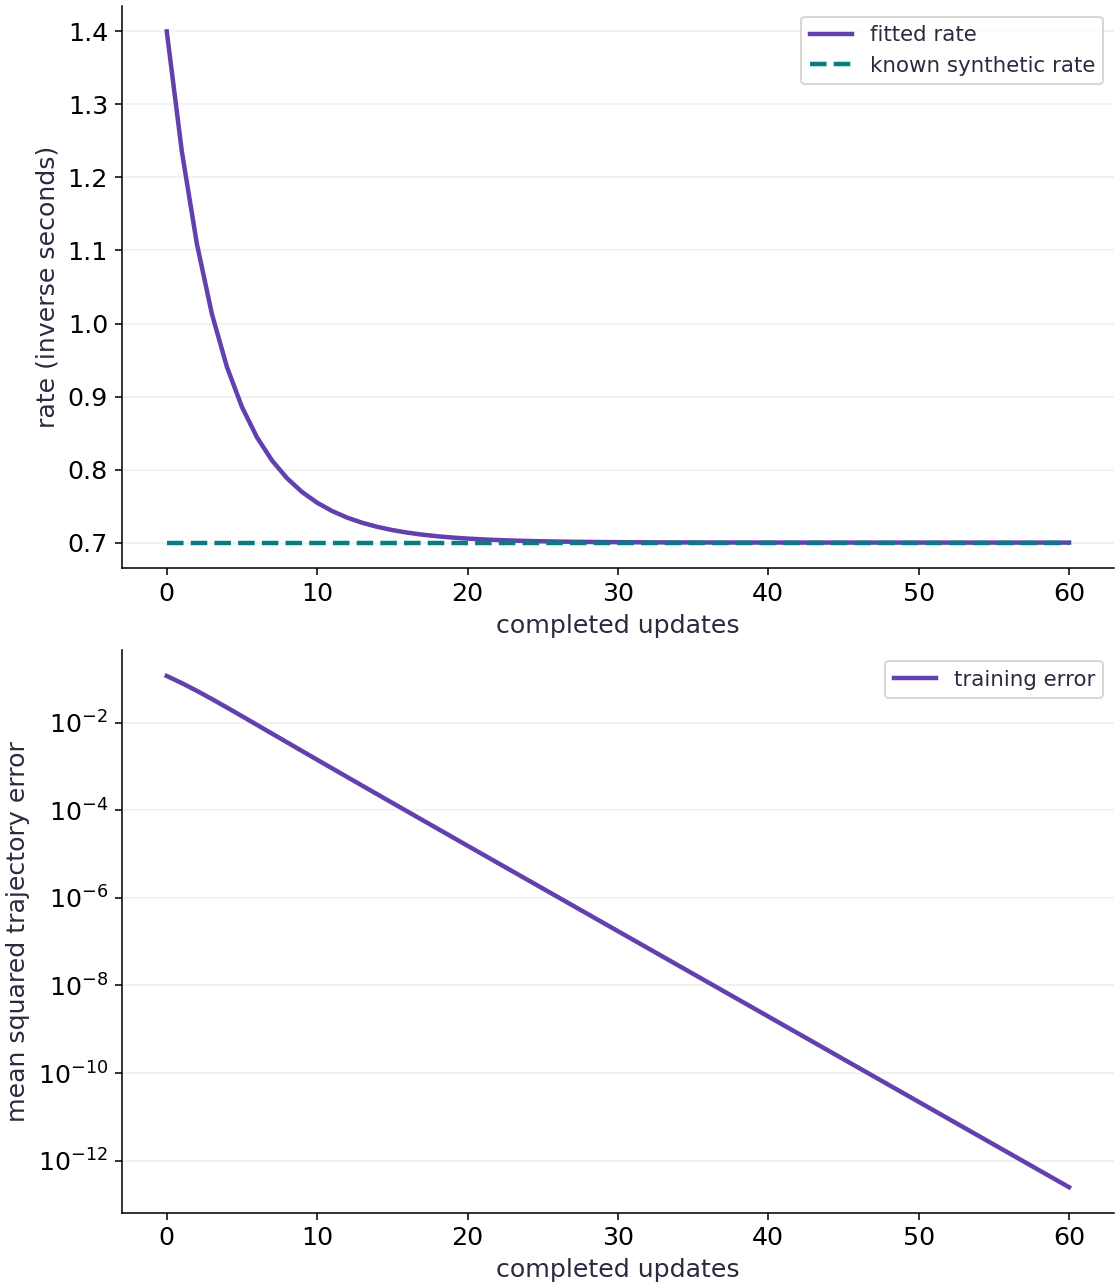

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The top panel shows the positive rate estimate versus completed optimizer updates. Update $0$ is the initial $1.4$, before training. The reference line is the known synthetic rate $0.7$. By update $20$, the fitted rate is about $0.7055$; by update $40$, about $0.70006$.

The lower panel shows mean squared trajectory error on a logarithmic scale. Its initial value is about $0.1168$, falling to about $1.55\times10^{-5}$ after twenty updates. The displayed first sixty updates focus on the informative descent rather than the eventual floating-point floor.

### Connect it to the computation

These recorded post-update values correspond to the same parameters shown above. The reference observations come from the analytic exponential, while fitting uses RK4, so agreement tests a numerical model against independently generated data.

A tiny final loss is plausible for noiseless synthetic data and a single smooth parameter. It is not an uncertainty estimate or proof about real instruments. Held-out starts, grid refinement and the deliberately biased Euler example provide the additional evidence needed to interpret the parameter.

## A perfect Euler fit can infer the wrong rate

Predict: Will a coarse Euler fit overestimate or underestimate the true cooling rate?

In [7]:
h=0.5
biased_rate=(1-np.exp(-true_rate*h))/h
coarse_times=np.arange(5)*h
matched=2*(1-biased_rate*h)**np.arange(5)
np.testing.assert_allclose(matched,2*np.exp(-true_rate*coarse_times),rtol=1e-12)
assert abs(biased_rate-true_rate)>0.1
print("True rate:",true_rate,"perfect coarse Euler rate:",biased_rate)

True rate: 0.7 perfect coarse Euler rate: 0.5906238205625731


Expected: True rate 0.7; Euler fit approximately 0.59062382.

The model parameter absorbs discretization error. Refining the numerical model is necessary before giving the estimate a physical interpretation.

## Measure fixed-shape CPU batches

Predict: Will total time and time per trajectory necessarily move in the same direction?

In [8]:
import time
measurements=[]
for batch_size in (1,16,256):
    starts=jnp.linspace(0.4,3.2,batch_size)
    compiled=jax.jit(lambda values:predict(fitted_rate,values))
    compiled(starts).block_until_ready()
    samples=[]
    for _ in range(7):
        beginning=time.perf_counter()
        compiled(starts).block_until_ready()
        samples.append((time.perf_counter()-beginning)*1000)
    median_ms=float(np.median(samples))
    assert median_ms>0
    measurements.append((batch_size,median_ms,median_ms/batch_size))
print("batch, median milliseconds, milliseconds per trajectory:",measurements)

batch, median milliseconds, milliseconds per trajectory: [(1, 0.006875023245811462, 0.006875023245811462), (16, 0.00762520357966423, 0.0004765752237290144), (256, 0.034500379115343094, 0.00013476710591930896)]


Expected: Measured positive timings vary by machine and load; the code makes no ordering or speedup assertion.

The warmed, synchronized boundary excludes compilation and explicit host-to-device transfer. Report the observed samples and device instead of copying a reference timing.

## Your exercise

Repeat inference for a new true rate $0.4$ using analytically generated observations, starting at $0.9$. Show that the recovered parameter and held-out predictions change consistently.

In [9]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [10]:
changed_truth=0.4
changed_observations=train_initials[:,None]*jnp.exp(-changed_truth*times)
def changed_objective(theta):
    return jnp.mean((predict(jnp.exp(theta),train_initials)-changed_observations)**2)
changed_update=jax.jit(lambda theta:theta-0.4*jax.grad(changed_objective)(theta))
changed_theta=jnp.log(0.9)
for _ in range(200):
    changed_theta=changed_update(changed_theta)
changed_rate=float(jnp.exp(changed_theta))
assert abs(changed_rate-changed_truth)<1e-6
changed_held=np.asarray(held_initials)[:,None]*np.exp(-changed_truth*np.asarray(times))
np.testing.assert_allclose(predict(changed_rate,held_initials),changed_held,rtol=2e-6,atol=1e-7)
print("Changed true/recovered rate:",changed_truth,changed_rate)

Changed true/recovered rate: 0.4 0.40000000054230433


## Infer a different physical quantity · Practice

Hold the rate fixed and estimate an unknown initial amplitude from a trajectory using linear least squares. Verify the estimate with a NumPy closed form.

Hint: At fixed rate, predictions are amplitude multiplied by a known decay vector.

In [11]:
# Write your attempt here.

## Reference reasoning

The inverse problem becomes linear when rate is fixed. Jointly unknown amplitude and rate require enough distinct observation times to distinguish their effects.

In [12]:
basis=np.exp(-0.7*np.asarray(times))
unknown_initial=2.8
measured=unknown_initial*basis
estimate=float(np.dot(basis,measured)/np.dot(basis,basis))
assert abs(estimate-unknown_initial)<1e-12
def amplitude_loss(amplitude):
    return jnp.mean((amplitude*jnp.asarray(basis)-jnp.asarray(measured))**2)
assert abs(float(jax.grad(amplitude_loss)(estimate)))<1e-12
print("Recovered initial amplitude:",estimate)

Recovered initial amplitude: 2.8000000000000003


## Compare noisy inference with an independent search · Challenge

Create a deterministic noisy dataset and quantify rate sensitivity with an independent grid search, without selecting a fit using held-out labels.

Hint: Search a dense one-dimensional grid using the analytic forward model and report the minimizing rate and residual scale.

In [13]:
# Write your attempt here.

## Reference reasoning

A noisy optimum need not equal the generating parameter exactly. One fixed-seed recovery check is not a calibrated uncertainty interval; repeated datasets or a justified statistical model are needed.

In [14]:
noisy=np.asarray(observations)+0.005*np.random.default_rng(19).normal(size=observations.shape)
candidates=np.linspace(0.65,0.75,1001)
reference_predictions=np.asarray(train_initials)[None,:,None]*np.exp(-candidates[:,None,None]*np.asarray(times)[None,None,:])
reference_losses=np.mean((reference_predictions-noisy[None,:,:])**2,axis=(1,2))
best=float(candidates[np.argmin(reference_losses)])
assert abs(best-0.7)<0.01
assert float(np.min(reference_losses))>0
print("Noisy grid-search estimate:",best,"residual MSE:",float(np.min(reference_losses)))

Noisy grid-search estimate: 0.7 residual MSE: 2.6000611439697964e-05


## Checkpoint

You fit only observations at time zero and every rate gives zero loss. What is the problem?

1. The batch is too small for a TPU.
2. The step size is too accurate.
3. The observations contain no information about the cooling rate.

## Diagnose

If the training loss is tiny but the parameter changes with step size, suspect solver bias. If every candidate has zero derivative, inspect observation times and parameter dependence before adjusting the optimizer. If timing results are implausibly tiny, confirm synchronization and warmup. If test performance drove your learning-rate choice, the test set is no longer untouched.

## Evidence

Full loss/rate histories, held-out and refined-grid metrics, noisy reference search, timing boundary and limitations. Keep the environment, observed outputs and your explanation of the figure.

## Carry forward

- Choose data that can reveal the parameter
- Enforce positivity through a parameterization
- Inspect the recovered model beyond the training curve
- Recognize observations that cannot identify a parameter
- Keep numerical bias separate from physical estimates
- Measure a bounded scaling experiment
- Move from this audit to a scientific workflow

## Primary references

- [JAX scan: fixed carry structure and reverse-mode differentiation](https://docs.jax.dev/en/latest/_autosummary/jax.lax.scan.html)
- [JAX automatic vectorization](https://docs.jax.dev/en/latest/_autosummary/jax.vmap.html)
- [JAX derivative checking and Jacobian products](https://docs.jax.dev/en/latest/notebooks/autodiff_cookbook.html)
- [Diffrax solver terms, saved values and solution inspection](https://docs.kidger.site/diffrax/usage/getting-started/)